# PopOut: The Game
### Trabalho realizado por:
- Ana Alves - up202407579
- Bárbara Castanho - up202406023
- Lara Queiroga - up202406713
### Introdução
Este trabalho foi realizado no âmbito da Unidade Curricular Inteligência Artificial (CC2006) com o objetivo de criar o jogo PopOut de forma a que seja possível haver jogos de humano vs humano, humano vs computador e computador vs computador. Os algoritmos implementados são o **Monte Carlo Tree Search (MCTS)** e **Decision Trees com o procedimento ID3**.

### Etapas do Trabalho
Neste projeto vamos:
1. Criar um jogo funcional, tendo em conta todas as regras dadas.
2. Implementar o algoritmo de Monte Carlo Tree Search (MCTS).
3. Implementar o algoritmo de Decision Trees com ID3.
    
    3.1. Teste usando o dataset dado "iris dataset".
    
    3.2. Teste final no jogo já criado, gerando o dataset com o MCTS.


---
### Importes
Por uma questão de organização colocamos todos os importes aqui.

In [1]:
import copy
import math
import random
import time
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import io, sys

---
## 1. Criação do Jogo

A primeira coisa que fizemos foi criar classes para organizar o código. Em Python, uma **classe** é uma forma de agrupar dados (atributos) e comportamentos (métodos) num único objeto. Por exemplo, a classe `Board` guarda o estado do tabuleiro e sabe como fazer drop, pop, verificar vitória, etc.

Optámos por 3 classes principais:
- **`Board`**: representa o tabuleiro 6×7, implementa os movimentos e as verificações de vitória
- **`Player`**: representa um jogador (humano ou IA), trata do input e da escolha de jogadas
- **`Game`**: gere o fluxo do jogo (turnos, regras especiais (empate por repetição, tabuleiro cheio, pop simultâneo))

Esta separação facilita a manutenção do código e permite ligar os algoritmos de IA (MCTS e Decision Tree) sem alterar a lógica do jogo.

### 1.1 Classe `Board`

O tabuleiro é uma matriz de 6 linhas × 7 colunas. A **linha 0 é o topo** e a **linha 5 é a base** (fundo). Os discos caem por gravidade, portanto um `drop` coloca sempre o disco na posição mais baixa disponível da coluna.

Decisões de implementação relevantes:
- `copy()` usa `deepcopy` para garantir que o MCTS pode simular jogadas sem alterar o tabuleiro real, e para testar se o moviment escolhido pelo jogador é válido.
- `to_tuple()` converte o grid num tuplo imutável, necessário para guardar o histórico de estados e detetar a regra das 3 repetições
- `to_flat_list()` vais ser usado depois pela decision tree

In [2]:
class Board:
    ROWS = 6
    COLS = 7
    EMPTY = '-'

    #cria uma matriz 6x7, tudo vazio
    def __init__(self):
        self.grid = [[self.EMPTY] * self.COLS for i in range(self.ROWS)]

    #dá print no terminal do board no estado atual
    def display(self):
        print()
        for row in self.grid:
            print(''.join(row))
        print()

    #dois movimentos permitidos, se nao forem possiveis as funçoes retornam false 
    def drop(self, col, player):
        for row in range(self.ROWS - 1, -1, -1):
            if self.grid[row][col] == self.EMPTY:
                self.grid[row][col] = player
                return True
        return False

    def pop(self, col, player):
        if not self.can_pop(col,player):
            return False
        for row in range(self.ROWS - 1, 0, -1):
            self.grid[row][col] = self.grid[row - 1][col]
        self.grid[0][col] = self.EMPTY
        return True

    #cenas de possiveis movimentos
    def can_pop(self, col, player):
        return self.grid[self.ROWS - 1][col] == player

    def get_valid_drops(self):
        return [col for col in range(self.COLS) if self.grid[0][col] == self.EMPTY]

    def get_valid_pops(self, player):
        return [col for col in range(self.COLS) if self.can_pop(col, player)]

    def get_all_moves(self, player):
        moves = [('drop', col) for col in self.get_valid_drops()]
        moves += [('pop', col) for col in self.get_valid_pops(player)]
        return moves

    #check win (e suas funções auxiliares)
    def check_win(self, player):
        return (
            self.check_horizontal(player) or
            self.check_vertical(player) or
            self.check_diag_going_right(player) or
            self.check_diag_going_left(player)
        )

    def check_horizontal(self, player):
        for row in range(self.ROWS):
            for col in range(self.COLS - 3):
                if (self.grid[row][col] == player and self.grid[row][col + 1] == player and
                    self.grid[row][col + 2] == player and self.grid[row][col + 3] == player):
                    return True
        return False

    def check_vertical(self, player):
        for row in range(self.ROWS - 3):
            for col in range(self.COLS):
                if (self.grid[row][col] == player and self.grid[row + 1][col] == player and
                    self.grid[row + 2][col] == player and self.grid[row + 3][col] == player):
                    return True
        return False

    def check_diag_going_right(self, player):
        for row in range(self.ROWS - 3):
            for col in range(self.COLS - 3):
                if (self.grid[row][col] == player and self.grid[row + 1][col+1] == player and
                    self.grid[row + 2][col+2] == player and self.grid[row + 3][col+3] == player):
                    return True
        return False

    def check_diag_going_left(self, player):
        for row in range(3, self.ROWS):
            for col in range(self.COLS - 3):
                if (self.grid[row][col] == player and self.grid[row - 1][col+1] == player and
                    self.grid[row - 2][col+2] == player and self.grid[row - 3][col+3] == player):
                    return True
        return False


    #funções uteis para depois(sobre o estado do board)
    def is_full(self):
        for row in range(self.ROWS):
            for col in range(self.COLS):
                if self.grid[row][col] == self.EMPTY:
                    return False
        return True

    def copy(self):
        new_board = Board()
        new_board.grid = copy.deepcopy(self.grid)
        return new_board

    def to_tuple(self):
        return tuple(tuple(row) for row in self.grid)

    def to_flat_list(self):
        return [cell for row in self.grid for cell in row]
    

### 1.2 Classe `Player`

A classe `Player` representa um jogador (humano ou IA). Contém os atributos `symbol` que representa o seu símbolo no tabuleiro e o atributo `is_human` que distingue humanos de IA. Quando `is_human==False`, o método `get_move` será substituído pela chamada ao algoritmo de IA correspondente (MCTS ou Decision Tree), que é passado como parâmetro `ai_func`.

In [3]:
class Player:
    def __init__(self, symbol, is_human=True, ai_func=None):
        self.symbol = symbol
        self.is_human = is_human
        self.ai_func = ai_func

    def get_move(self, board):
        if not self.is_human:
            return self.ai_func(board, self.symbol)

        print(f"É a vez de {self.symbol}")

        while True:
            #escolher um tipo de jogada valido
            while True:
                print("  Tipo de jogada (drop/pop)")
                move_type = input().strip().lower()
                if move_type in ('drop', 'pop'):
                    break
                print("  Escolhe 'drop' ou 'pop'.")

            #escolher uma coluna
            while True:
                try:
                    print("  Coluna (0-6)")
                    col = int(input( ))
                except ValueError:
                    print("  Introduz um número válido.")
                    continue 

                if col not in range(7):
                    print("  Coluna inválida. Escolhe entre 0 e 6.")
                    continue 

                break

            test_board = board.copy()
            if move_type == 'drop':
                valid = test_board.drop(col, self.symbol)
            else:
                valid = test_board.pop(col, self.symbol)

            if not valid:
                print("  Jogada inválida. Escolhe outro tipo de jogada e coluna.")
                continue

            return (move_type, col)

    def __str__(self):
        return self.symbol

### 1.3 Classe `Game`

A classe `Game` gere o loop principal do jogo e implementa as **3 regras especiais do PopOut**:

1. **Pop simultâneo**: se um pop cria 4 em linha para ambos os jogadores, quem fez o pop ganha.
2. **Tabuleiro cheio**: o jogador a mover pode optar por declarar empate em vez de jogar.
3. **Repetições**: se o mesmo estado do tabuleiro se repetir 3 vezes, o jogo é empate.

O histórico de estados é guardado num dicionário {estado: contagem}, onde o estado é o resultado de board.to_tuple() (um tuplo imutável que pode ser usado como chave de dicionário).

Mais tarde foi adicionado o atributo collect_data ao `__init__` para facilitar a criação do dataset para treinar a decision tree. Este só será true na criação desta dataset.

In [4]:
class Game:
    def __init__(self, collect_data = False):
        self.board = Board()
        self.players = []
        self.history = {}
        self.current_idx = 0 
        self.collect_data = collect_data
        self.dataset = [] #so usado se collect_data for true

    def switch_player(self):
        self.current_idx = 1 - self.current_idx

    def record_state(self):
        state = self.board.to_tuple()
        self.history[state] = self.history.get(state, 0) + 1
        return self.history[state]

    #loop principal do jogo (retorna quem ganha)
    def run(self):
        if not self.players:
            print('\n=== BEM-VINDO AO POPOUT ===')
            print('Modos disponíveis:')
            print('  1. Humano vs Humano')
            print('  2. Humano vs MCTS')
            print('  3. Humano vs Decision Tree')
            print('  4. MCTS vs Decision Tree')

            while True:
                try:
                    mode = int(input('\nEscolhe o modo (1-4): '))
                    if mode in (1, 2, 3, 4):
                        break
                    print('Escolhe entre 1 e 4.')
                except ValueError:
                    print('Introduz um número válido.')

            if mode == 1:
                self.players = [Player('X'), Player('O')]
            elif mode == 2:
                self.players = [Player('X'), Player('O', is_human=False, ai_func=mcts)]
            elif mode == 3:
                self.players = [Player('X'), Player('O', is_human=False, ai_func=dt_move)]
            else:
                self.players = [Player('X', is_human=False, ai_func=mcts),
                                Player('O', is_human=False, ai_func=dt_move)]
                print("\nComeçou o jogo!!")
                print(f"    {self.players[0]}  vs  {self.players[1]}")
                print("=" * 16)

        while True:
            self.board.display()
            player = self.players[self.current_idx]

            #regra 2
            if self.board.is_full():
                print("O tabuleiro está cheio!")
                if player.is_human:
                    choice = input(
                        f"{player.symbol}, queres fazer pop ou declarar empate? (pop/empate): "
                    ).strip().lower()
                    if choice == 'empate':
                        print("\nEmpate declarado! Tabuleiro cheio.")
                        return 'draw'
                else:
                    pass

            #fazer jogada
            move_type, col = player.get_move(self.board)
            if not player.is_human:
                print(f"  {player.symbol} jogou: {move_type} na coluna {col}")

            if self.collect_data:
                self.dataset.append((self.board.to_flat_list(), f'{move_type}_{col}'))
            
            result = self.apply_move(move_type, col, player)

            if result == 'win':
                self.board.display()
                winner = self.players[self.current_idx] 
                print(f"\n{winner.symbol} GANHOU!")
                return winner.symbol

            if result == 'draw':
                self.board.display()
                print("\nEmpate!")
                return 'draw'

            #regra 3
            count = self.record_state()
            if count == 3:
                self.board.display()
                print(f"\nEstado repetido 3 vezes. Empate por repetição!")
                return 'draw'

            self.switch_player()

    #aplica o movimento e diz se alguem ganhou ou nao
    def apply_move(self, move_type, col, player):
        if move_type == 'drop':
            self.board.drop(col, player.symbol)
            if self.board.check_win(player.symbol):
                return 'win'

        elif move_type == 'pop':
            self.board.pop(col, player.symbol)
            player_wins   = self.board.check_win(player.symbol)
            opponent_wins = self.board.check_win(self.players[1 - self.current_idx].symbol)

            if player_wins:
                #regra 1
                return 'win'
            elif opponent_wins:
                self.current_idx = 1 - self.current_idx
                return 'win'
        return None

### 1.4 Teste rápido do jogo (Humano vs Humano)

Para testar a lógica do jogo nós usámos o código abaixo temporariamente e escolhemos a opcção inicial de humano vs humano. Encontra-se comentado pois foi criado apenas para teste e não tencionamos que seja corrido no final.

In [5]:
'''
game = Game()
game.run()'''

'\ngame = Game()\ngame.run()'

---
## 2. Monte Carlo Tree Search (MCTS)

Agora que temos a parte do jogo em si funcional vamos passar à implementação dos algoritmos. O **Monte Carlo Tree Search** é um algoritmo de pesquisa adversarial baseado em simulações aleatórias. Em vez de explorar toda a árvore de jogo (como o Minimax), o MCTS faz simulações (*playouts*) até ao fim do jogo para estimar o valor de cada jogada.

### As 4 fases do MCTS

1. **Seleção**: a partir da raiz, desce na árvore escolhendo o nó filho com maior UCT até chegar a um nó não totalmente expandido
2. **Expansão**: adiciona um novo nó filho ao nó selecionado
3. **Simulação** (*rollout*): a partir do novo nó, simula o jogo até ao fim com jogadas aleatórias
4. **Retropropagação**: propaga o resultado da simulação de volta até à raiz, atualizando visitas e vitórias

### UCT (Upper Confidence Bound for Trees)

A fórmula UCT equilibra exploração e exploração:

$$UCT = \frac{w_i}{n_i} + C \cdot \sqrt{\frac{\ln N}{n_i}}$$

Onde:
- $w_i$ = número de vitórias no nó $i$
- $n_i$ = número de visitas ao nó $i$
- $N$ = número de visitas ao nó pai
- $C$ = constante de exploração (tipicamente $\sqrt{2}$)

Nós não visitados têm UCT = ∞, garantindo que são explorados primeiro.

In [6]:
#classe dos nós, cada nó guarda o estado do jogo
class MCTSNode:
    def __init__(self, board, player, move=None, parent=None):
        self.board   = board    #estado do tabuleiro neste nó
        self.player  = player   #jogador que jogou para chegar a este estado
        self.move    = move     #(tipo, col) que gerou este nó
        self.parent  = parent
        self.children = []

        self.visits = 0
        self.wins   = 0

        #jogadas ainda não exploradas a partir deste estado
        opponent = 'O' if player == 'X' else 'X'
        self.untried_moves = board.get_all_moves(opponent)

    #uct deste nó
    def uct_score(self, c = math.sqrt(2)):
        if self.visits == 0:
            return float('inf')
        return (self.wins / self.visits) + (c * math.sqrt(math.log(self.parent.visits) / self.visits))

    #retorna true se ja visitou todos os filhos
    def is_fully_expanded(self):
        return len(self.untried_moves) == 0

    #filho com maior uct
    def best_child(self, c= math.sqrt(2)):
        return max(self.children, key=lambda child: child.uct_score(c=c))


#mcts principal(retorna o melhor movimento)
def mcts(board, player, n_simulations=500, k_children=1, c = math.sqrt(2)):
    opponent = 'O' if player == 'X' else 'X'

    #a raiz será o estado atual e o player anterior foi o adversário
    root = MCTSNode(board.copy(), opponent)

    for i in range(n_simulations):
        node = root

        #fase 1(seleção)
        while node.is_fully_expanded() and node.children:
            node = node.best_child(c=c)

        #fase 2(expansão)
        for i in range(k_children):
            if node.untried_moves:
                move = random.choice(node.untried_moves)
                node.untried_moves.remove(move)

                new_board = node.board.copy()
                next_player = 'O' if node.player == 'X' else 'X'
                if move[0] == 'drop':
                    new_board.drop(move[1], next_player)
                else:
                    new_board.pop(move[1], next_player)

                child = MCTSNode(new_board, next_player, move=move, parent=node)
                node.children.append(child)
                node = child

        #fase 3(simulação)
        result = rollout(node.board.copy(), node.player)

        #fase 4(retropropagação)
        backpropagate(node, result, player)

    #escolhe o filho mais visitado (mais robusto que o de maior taxa de vitórias)
    best = max(root.children, key=lambda c: c.visits)
    return best.move


#funçaõ fase 3
def rollout(board, last_player):
    current = 'O' if last_player == 'X' else 'X'
    history = {}

    for i in range(200):  #para evitar loops infinitos
        #verificar se ganhou
        if board.check_win(last_player):
            return last_player

        moves = board.get_all_moves(current)
        if not moves:
            return 'draw'

        if board.is_full():
            return 'draw'

        move = random.choice(moves)
        if move[0] == 'drop':
            board.drop(move[1], current)
        else:
            board.pop(move[1], current)

        #regra das repetições (simplificada no rollout)
        state = board.to_tuple()
        history[state] = history.get(state, 0) + 1
        if history[state] >= 3:
            return 'draw'

        last_player, current = current, last_player

    return 'draw'

#função fase 4
def backpropagate(node, result, root_player):
    while node is not None:
        node.visits += 1
        if result == node.player:
            node.wins += 1
        node = node.parent

### 2.1 Testes do MCTS

Agora para testar o MCTS usámos um tabuleiro meio preenchido igual para todos os testes. O objetivo seria o modelo escolher a jogada `pop_2` que dá vitória imediata ou `drop_3` que dá vitória na jogada seguinte.

O primeiro teste feito foi para ver o valor ideal de simulações que o monte carlo faz. Testámos os valores 100, 300, 500 e 1000.



-------
-------
-------
X-X----
OXOXX--
XOXXOO-



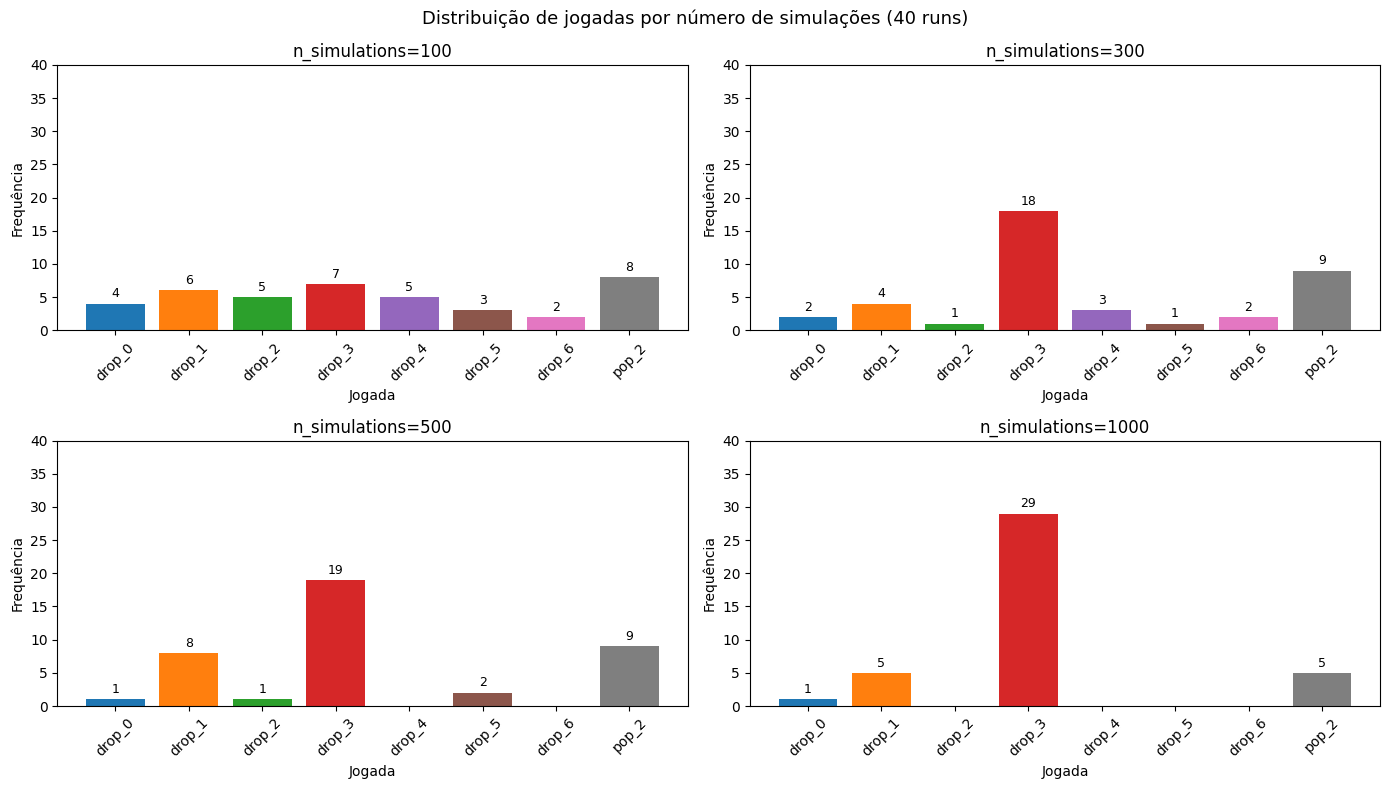

In [7]:
test_board = Board()
test_board.drop(0, 'X')
test_board.drop(0, 'O')
test_board.drop(0, 'X')
test_board.drop(1, 'O')
test_board.drop(2, 'X')
test_board.drop(3, 'X')
test_board.drop(1, 'X')
test_board.drop(2, 'O')
test_board.drop(2, 'X')
test_board.drop(3, 'X')
test_board.drop(4, 'O')
test_board.drop(4, 'X')
test_board.drop(5, 'O')
test_board.display()

n_sims_list = [100, 300, 500, 1000]
n_runs = 40
results = {n: [] for n in n_sims_list}

for n_sims in n_sims_list:
    for _ in range(n_runs):
        move = mcts(test_board, 'X', n_simulations=n_sims)
        results[n_sims].append(f'{move[0]}_{move[1]}')

# todos os moves distintos que apareceram
all_moves = sorted(set(m for moves in results.values() for m in moves))
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribuição de jogadas por número de simulações (40 runs)', fontsize=13)

for ax, n_sims in zip(axes.flat, n_sims_list):
    counts = Counter(results[n_sims])
    values = [counts.get(m, 0) for m in all_moves]
    bars = ax.bar(all_moves, values, color=colors[:len(all_moves)])
    ax.set_title(f'n_simulations={n_sims}')
    ax.set_xlabel('Jogada')
    ax.set_ylabel('Frequência')
    ax.set_ylim(0, n_runs)
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Ao observar os resultados podemos ver que quando o número de simulações é 500 dá resultados muito menos dispersos do que para 100 ou 300 e os movimentos mais frequentes são os dois ideais (embora o que dá vitória imediata não ser o mais frequente). Também podemos observar que a diferença entre 500 e 1000 iterações é pouco significante, embora 1000 seja melhor, mas como o tempo de execução de 1000 é bastante mais alto achámos que o melhor valor para implemnetar seria 500.

De seguinta testamos vários valores da constante de exploração C. Testamos os valores 0.5, 1, raiz de 2 e 2.

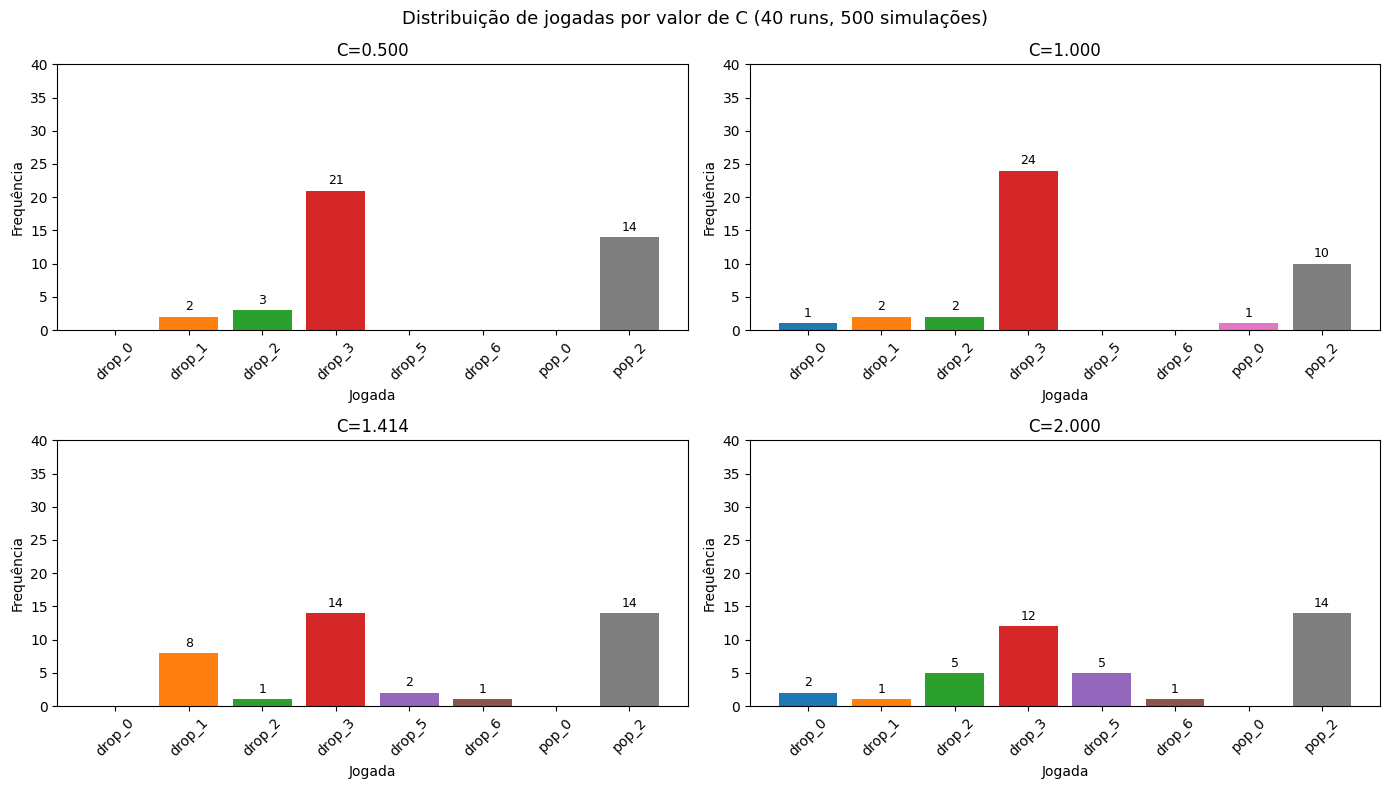

In [8]:
c_values = [0.5, 1.0, math.sqrt(2), 2.0]
n_runs = 40
results_c = {c: [] for c in c_values}

for c in c_values:
    for _ in range(n_runs):
        move = mcts(test_board, 'X', n_simulations=500, c=c)
        results_c[c].append(f'{move[0]}_{move[1]}')

all_moves = sorted(set(m for moves in results_c.values() for m in moves))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribuição de jogadas por valor de C (40 runs, 500 simulações)', fontsize=13)

for ax, c in zip(axes.flat, c_values):
    counts = Counter(results_c[c])
    values = [counts.get(m, 0) for m in all_moves]
    bars = ax.bar(all_moves, values, color=colors[:len(all_moves)])
    ax.set_title(f'C={c:.3f}')
    ax.set_xlabel('Jogada')
    ax.set_ylabel('Frequência')
    ax.set_ylim(0, n_runs)
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Aqui podémos observar que os resultados variavam bastante sempre que se corria o código. Devido a esta inconsistência e à diferença ser pouco significativa entreos diferentes valores de c, como o valor mais comum de ser usado é raiz de 2 foi esse que implementámos.

Por último, testámos se mudássemos o número de filhos expandidos os resultados alteravam.

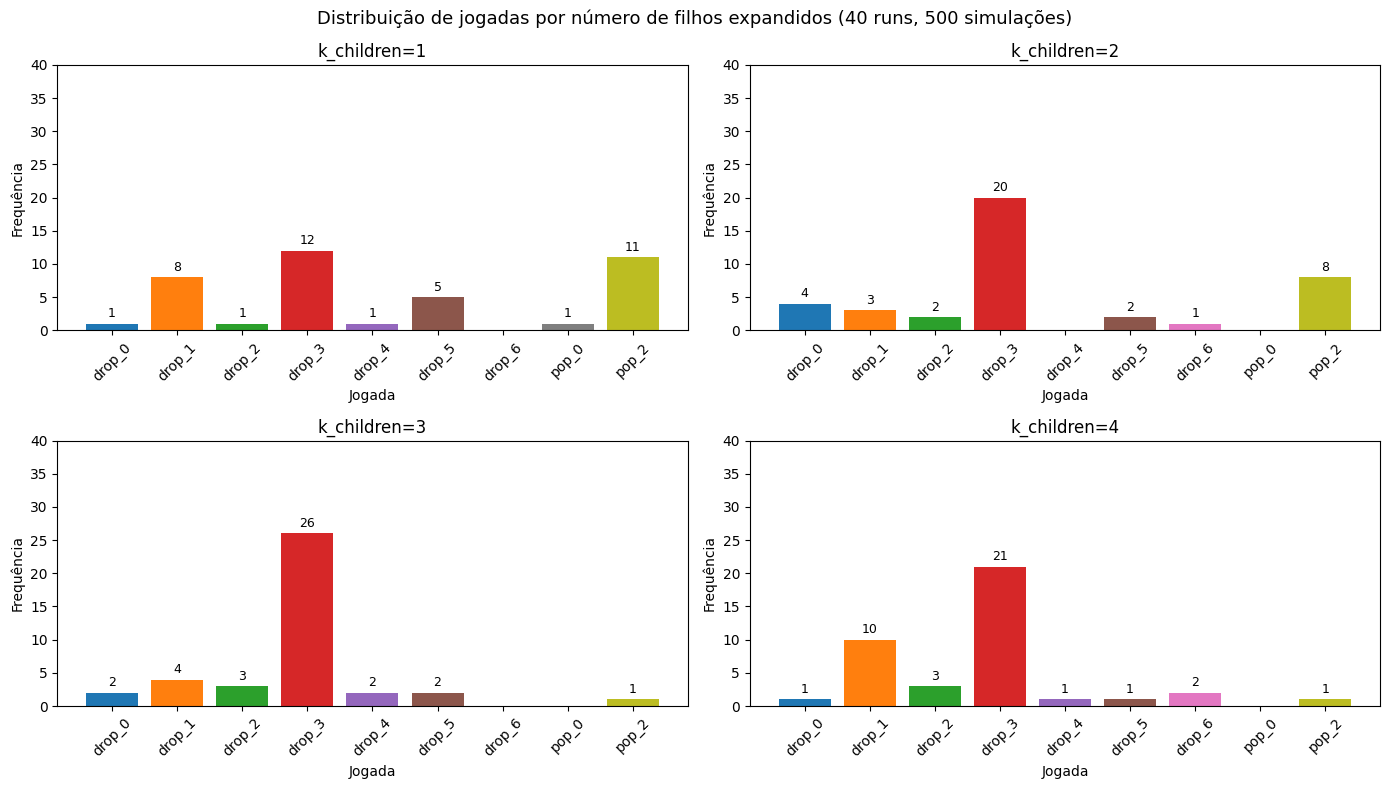

In [9]:
k_values = [1, 2, 3, 4]
results_k = {k: [] for k in k_values}

for k in k_values:
    for _ in range(n_runs):
        move = mcts(test_board, 'X', n_simulations=500, k_children=k)
        results_k[k].append(f'{move[0]}_{move[1]}')

all_moves = sorted(set(m for moves in results_k.values() for m in moves))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribuição de jogadas por número de filhos expandidos (40 runs, 500 simulações)', fontsize=13)

for ax, k in zip(axes.flat, k_values):
    counts = Counter(results_k[k])
    values = [counts.get(m, 0) for m in all_moves]
    bars = ax.bar(all_moves, values, color=colors[:len(all_moves)])
    ax.set_title(f'k_children={k}')
    ax.set_xlabel('Jogada')
    ax.set_ylabel('Frequência')
    ax.set_ylim(0, n_runs)
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Ao analisar os resultados, o `drop_3` domina em todos os valores de k, o que é esperado dado que garante vitória no turno seguinte. No entanto, os resultados variam bastante entre execuções devido à variância natural do MCTS (os mesmos parâmetros podem produzir distribuições diferentes). Isto dificulta tirar conclusões definitivas sobre o impacto do número de filhos, sendo a aleatoriedade dos rollouts o fator dominante na variação observada.

In [ ]:
#para jogar Humano vs MCTS, descomentar e escolher 2
'''
game = Game()
game.run()'''


=== BEM-VINDO AO POPOUT ===
Modos disponíveis:
  1. Humano vs Humano
  2. Humano vs MCTS
  3. Humano vs Decision Tree
  4. MCTS vs Decision Tree

-------
-------
-------
-------
-------
-------

É a vez de X
  Tipo de jogada (drop/pop)
  Coluna (0-6)

-------
-------
-------
-------
-------
-X-----

  O jogou: drop na coluna 3

-------
-------
-------
-------
-------
-X-O---

É a vez de X
  Tipo de jogada (drop/pop)
  Coluna (0-6)

-------
-------
-------
-------
---X---
-X-O---

  O jogou: drop na coluna 3

-------
-------
-------
---O---
---X---
-X-O---

É a vez de X
  Tipo de jogada (drop/pop)
  Coluna (0-6)

-------
-------
-------
---O---
---X---
-X-OX--

  O jogou: drop na coluna 1

-------
-------
-------
---O---
-O-X---
-X-OX--

É a vez de X
  Tipo de jogada (drop/pop)
  Coluna (0-6)

-------
-------
-------
---O---
-O-X---
XX-OX--

  O jogou: drop na coluna 1

-------
-------
-------
-O-O---
-O-X---
XX-OX--

É a vez de X
  Tipo de jogada (drop/pop)
  Coluna (0-6)

-------
---

'O'

---
## 3. Decision Trees com ID3

O algoritmo **ID3** (Iterative Dichotomiser 3) constrói uma árvore de decisão a partir de um dataset de treino, escolhendo em cada nó o atributo que mais reduz a **entropia** do conjunto ou seja, o atributo com maior **ganho de informação**.

### Conceitos fundamentais

**Entropia** mede a impureza de um conjunto:
$$H(S) = -\sum_{c} p_c \cdot \log_2(p_c)$$

**Ganho de informação** mede o quanto um atributo reduz a entropia:
$$\text{Gain}(S, A) = H(S) - \sum_{v \in A} \frac{|S_v|}{|S|} \cdot H(S_v)$$

O ID3 escolhe sempre o atributo com maior ganho de informação para dividir o conjunto.

**Nota**: não usamos scikit-learn, a implementação é feita de raiz, conforme exigido pelo enunciado.

**Nota 2**: não foi implementada nenhuma maneira de lidar com valores nulos uma vez que ambos os datasets usados neste trabalho não contêm nenhum.

In [12]:
#funcoes auxiliares
def entropy(labels):
    if not labels:
        return 0.0
    counts = Counter(labels)
    total  = len(labels)
    return -sum(
        (count / total) * math.log2(count / total)
        for count in counts.values() if count > 0
    )

def information_gain(data, labels, feature_idx):
    total  = len(labels)
    h_s    = entropy(labels)

    subsets = {}
    for i, row in enumerate(data):
        val = row[feature_idx]
        if val not in subsets:
            subsets[val] = []
        subsets[val].append(labels[i])

    weighted_entropy = sum(
        (len(subset) / total) * entropy(subset)
        for subset in subsets.values()
    )

    return h_s - weighted_entropy

#classe com nós 
class DecisionTreeNode:
    def __init__(self, is_leaf=False, label=None, feature_idx=None, feature_name=None):
        self.is_leaf      = is_leaf
        self.label        = label        #so nos nós folha 
        self.feature_idx  = feature_idx
        self.feature_name = feature_name #para visualização
        self.children     = {}

#recursão para criar a arvore toda
def id3(data, labels, feature_indices, feature_names=None, depth=0, max_depth=None):
    #casos base
    #todos os exemplos são da mesma classe
    if len(set(labels)) == 1:
        return DecisionTreeNode(is_leaf=True, label=labels[0])

    #não haver mais atributos
    if not feature_indices:
        majority = Counter(labels).most_common(1)[0][0]
        return DecisionTreeNode(is_leaf=True, label=majority)

    #profundidade maxima
    if max_depth is not None and depth >= max_depth:
        majority = Counter(labels).most_common(1)[0][0]
        return DecisionTreeNode(is_leaf=True, label=majority)

    #atributo com maior ganho de informação(por onde vai separar)
    best_idx  = max(feature_indices, key=lambda idx: information_gain(data, labels, idx))
    best_name = feature_names[best_idx] if feature_names else str(best_idx)

    node = DecisionTreeNode(feature_idx=best_idx, feature_name=best_name)

    #divisão do dataset
    values = set(row[best_idx] for row in data)
    remaining = [idx for idx in feature_indices if idx != best_idx]

    for val in values:
        sub_data   = [data[i]   for i in range(len(data))   if data[i][best_idx] == val]
        sub_labels = [labels[i] for i in range(len(labels)) if data[i][best_idx] == val]

        if not sub_data: #caso de um valor de um atributo nunca aparecer junto com certos labels no treino
            majority = Counter(labels).most_common(1)[0][0]
            node.children[val] = DecisionTreeNode(is_leaf=True, label=majority)
        else:
            node.children[val] = id3(sub_data, sub_labels, remaining, feature_names, depth + 1, max_depth)

    return node

def predict(tree, example):
    node = tree
    while not node.is_leaf:
        val = example[node.feature_idx]
        if val not in node.children:
            return None  #se tiver um valor que nao esta no treino retorna none
        node = node.children[val]
    return node.label

def accuracy(tree, data, labels):
    return sum(1 for i, ex in enumerate(data) if predict(tree, ex) == labels[i]) / len(labels) if labels else 0.0

def print_tree(node, indent=0, value=None):
    prefix = '  ' * indent
    if value is not None:
        prefix += f'[{value}] '
    if node.is_leaf:
        print(f'{prefix}→ {node.label}')
    else:
        print(f'{prefix}{node.feature_name}')
        for val, child in sorted(node.children.items(), key=lambda x: str(x[0])):
            print_tree(child, indent + 1, value=val)

### 3.1 Teste com o dataset Iris

O **Iris dataset** contém 4 atributos numéricos (comprimento/largura de sépalas e pétalas) de 3 espécies de flores. Como o ID3 foi projetado para atributos categóricos, precisamos de **discretizar** os valores numéricos, como foi mencionado no guião dado.

A estratégia de discretização escolhida foi dividir cada atributo em 3 bins de igual largura: `baixo`, `médio`, `alto`. Esta abordagem é simples e reduz a profundidade da árvore sem perder informação relevante.

In [13]:
IRIS_FEATURE_NAMES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

def load_iris_raw():
    data, labels = [], []
    with open('iris.csv', 'r') as f:
        header = f.readline() #ignorar a primeira linha com os nomes dos atributos
        for line in f:
            parts = line.strip().split(',')
            data.append([float(x) for x in parts[1:5]])
            labels.append(parts[5])
    return data, labels

#funções para discretizar
def get_thresholds(data):
    thresholds = []
    for f in range(len(data[0])):
        vals = [row[f] for row in data]
        step = (max(vals) - min(vals)) / 3
        thresholds.append([min(vals) + step * i for i in range(1, 3)])
    return thresholds

def discretize(data):
    bin_labels = ['baixo', 'médio', 'alto']
    thresholds = get_thresholds(data)
    result = []
    for row in data:
        disc_row = []
        for f, val in enumerate(row):
            bin_idx = sum(1 for t in thresholds[f] if val > t)
            disc_row.append(bin_labels[bin_idx])
        result.append(disc_row)
    return result


iris_data_raw, iris_labels = load_iris_raw()
iris_data = discretize(iris_data_raw)

Agora vamos passar ao treino e teste da nossa implementação. Nós decidimos usar `Stratified 5-fold Cross-validation`. Escolhemos Stratified em vez de uma implementação do cross-validation normal uma vez que observamos que no dataset os exemplos da mesma classe estão agregados, o que nos obriga a ter isso em conta para ter resultados fiáveis.

In [14]:
def stratified_cross_validation(data, labels, feature_names=None, max_depth= None):
    random.seed(42)
    k = 5

    class_indices = {}
    for i, label in enumerate(labels):
        if label not in class_indices:
            class_indices[label] = []
        class_indices[label].append(i)

    folds = [[] for j in range(k)]
    for label, indices in class_indices.items():
        fold_size = len(indices) // k
        for i in range(k):
            folds[i] += indices[i * fold_size:(i + 1) * fold_size]

    results = []  # lista de (tree, test_data, test_labels, predictions)
    for i in range(k):
        test_idx  = folds[i]
        train_idx = [idx for j, fold in enumerate(folds) if j != i for idx in fold]

        train_data   = [data[idx]   for idx in train_idx]
        train_labels = [labels[idx] for idx in train_idx]
        test_data    = [data[idx]   for idx in test_idx]
        test_labels  = [labels[idx] for idx in test_idx]

        feature_indices = list(range(len(data[0])))
        tree        = id3(train_data, train_labels, feature_indices, feature_names=feature_names, max_depth=max_depth)
        predictions = [predict(tree, ex) for ex in test_data]

        results.append((tree, test_data, test_labels, predictions))

    return results

iris_cv = stratified_cross_validation(iris_data, iris_labels, feature_names=IRIS_FEATURE_NAMES)
dt_acc = []
for i, (tree, test_data, test_labels, predictions) in enumerate(iris_cv):
    if i == 0:
        print_tree(tree)
        print('\n')
    acc = accuracy(tree, test_data, test_labels)
    dt_acc.append(acc)
    print(f'Fold {i+1}: {acc:.1%}')
    #print_tree(tree)

media = sum(dt_acc) / len(dt_acc)
print(f'\nMédia: {media:.1%}')

petal_width
  [alto] petal_length
    [alto] → Iris-virginica
    [médio] sepal_width
      [baixo] → Iris-virginica
      [médio] sepal_length
        [médio] → Iris-virginica
  [baixo] → Iris-setosa
  [médio] petal_length
    [alto] sepal_length
      [alto] → Iris-virginica
      [médio] sepal_width
        [baixo] → Iris-virginica
        [médio] → Iris-versicolor
    [médio] → Iris-versicolor


Fold 1: 96.7%
Fold 2: 100.0%
Fold 3: 90.0%
Fold 4: 90.0%
Fold 5: 100.0%

Média: 95.3%


#### Discussão dos resultados (Iris) 
O ID3 atinge uma média de 95.3% de accuracy no dataset Iris com discretização em 3 bins. A árvore resultante é relativamente pequena e interpretável: o atributo `petal_width` (ou `petal_length`) é geralmente escolhido como raiz, pois apresenta o maior ganho de informação  (estas pétalas separam a espécie *setosa* das outras duas com entropia zero). No código acima mostramos o exemplo da decision tree criada pelo primeiro fold.

A discretização em 3 bins pode introduzir alguma perda de informação nos limites, mas mantém a árvore compacta e evita overfitting.



### 3.2 Decision Tree para o PopOut

Para usar a Decision Tree no PopOut, precisamos de:
1. **Gerar um dataset** de pares `(estado, melhor_jogada)` usando o MCTS
2. **Representar o estado** como uma lista de features categóricas
3. **Treinar a árvore ID3** com o dataset gerado
4. **Usar a árvore** como IA no jogo

#### Representação do estado
Cada célula do tabuleiro é um atributo: `'-'` (vazio), `'X'` ou `'O'`. O tabuleiro 6×7 gera 42 features. O label é a jogada sugerida pelo MCTS, codificada como string: `'drop_3'`, `'pop_1'`, etc.

In [15]:
def generate_popout_dataset(n_games=750):
    dataset = []
    for i in range(n_games):
        game = Game(collect_data=True)
        game.players = [
            Player('X', is_human=False, ai_func=lambda b, s: mcts(b, s)),
            Player('O', is_human=False, ai_func=lambda b, s: mcts(b, s))
        ]
        
        #correr o jogo mas sem dar output de cada estado
        old_stdout = sys.stdout
        sys.stdout = io.StringIO()
        game.run()
        sys.stdout = old_stdout

        dataset += game.dataset
        if (i + 1) % 50 == 0:
            print(f'  {i+1}/{n_games} partidas ({len(dataset)} exemplos)...')
    return dataset

print('A gerar dataset com MCTS (pode demorar)...')
start = time.time()
popout_dataset = generate_popout_dataset()
print(f'Tempo total: {time.time() - start:.1f}s')

popout_features = [ex[0] for ex in popout_dataset]
popout_labels   = [ex[1] for ex in popout_dataset]

for move, count in Counter(popout_labels).most_common():
    print(f'  {move}: {count}')

A gerar dataset com MCTS (pode demorar)...
  50/750 partidas (699 exemplos)...
  100/750 partidas (1436 exemplos)...
  150/750 partidas (2208 exemplos)...
  200/750 partidas (2895 exemplos)...
  250/750 partidas (3609 exemplos)...
  300/750 partidas (4291 exemplos)...
  350/750 partidas (5016 exemplos)...
  400/750 partidas (5746 exemplos)...
  450/750 partidas (6426 exemplos)...
  500/750 partidas (7143 exemplos)...
  550/750 partidas (7918 exemplos)...
  600/750 partidas (8663 exemplos)...
  650/750 partidas (9409 exemplos)...
  700/750 partidas (10134 exemplos)...
  750/750 partidas (10806 exemplos)...
Tempo total: 2193.4s
  drop_3: 2727
  drop_2: 1969
  drop_4: 1959
  drop_1: 1282
  drop_5: 1264
  drop_0: 688
  drop_6: 618
  pop_2: 55
  pop_3: 54
  pop_4: 54
  pop_1: 52
  pop_5: 46
  pop_6: 22
  pop_0: 16


Depois de criado o dataset podemos observar que este apresenta um desequilíbrio muito grande, onde os drops dominam largamente sobre os pops. Isto deve-se ao facto de o MCTS, especialmente nas fases iniciais do jogo, preferir sistematicamente jogadas de drop nas colunas centrais (particularmente drop_3 e drop_4) por serem posições estrategicamente mais fortes num tabuleiro vazio. Os pops só se tornam relevantes em estados avançados do jogo onde existem discos na base, o que acontece com muito menos frequência ao longo de uma partida. Este desequilíbrio espera-se ter um grande impacto na Decision Tree, uma vez que o algoritmo ID3 tende a favorecer as classes mais representadas no treino, levando a que a árvore aprenda bem a prever drops mas tenha dificuldade em identificar situações onde um pop seria a jogada correta.

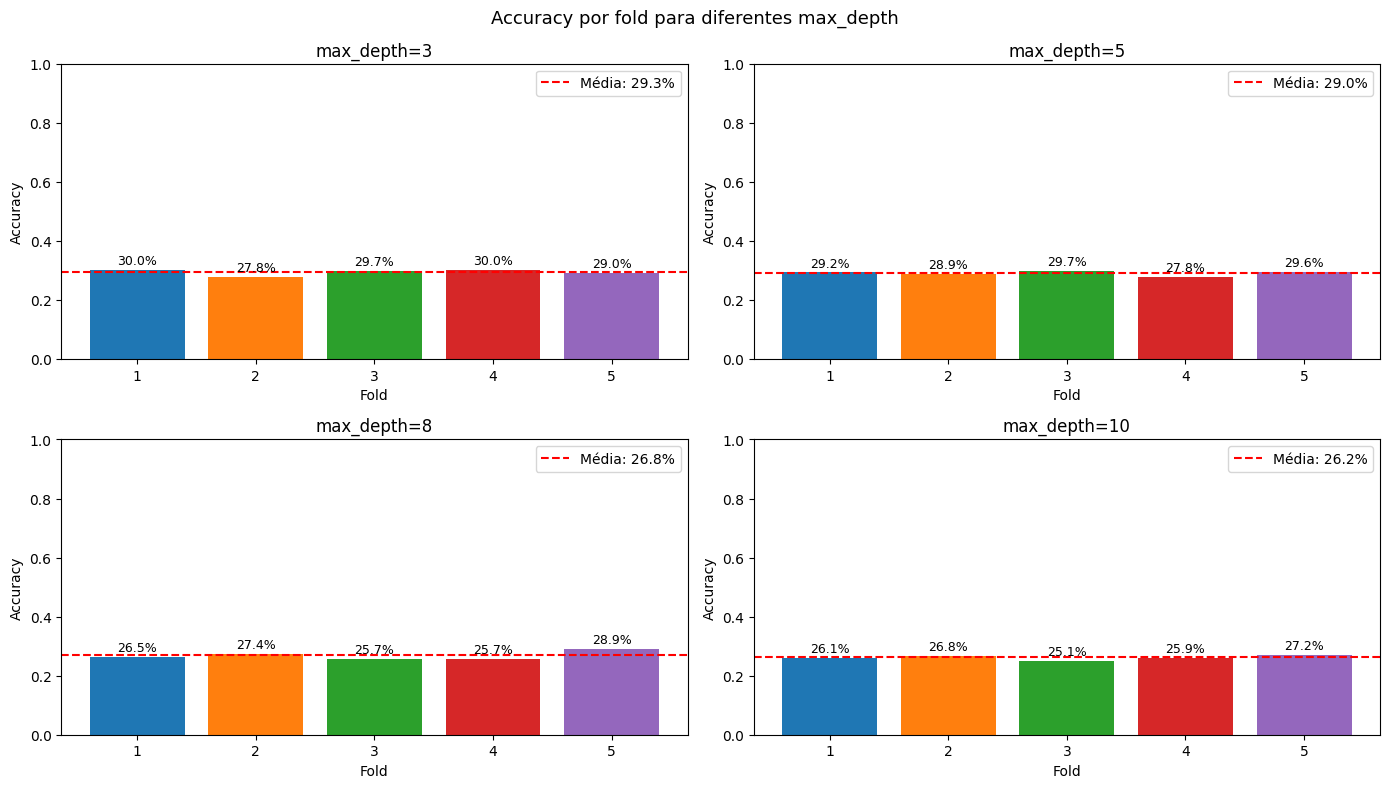

In [16]:
depth_values = [3, 5, 8, 10]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Accuracy por fold para diferentes max_depth', fontsize=13)

for ax, depth in zip(axes.flat, depth_values):
    cv = stratified_cross_validation(popout_features, popout_labels, max_depth=depth)
    accuracies = []
    for tree, test_data, test_labels, predictions in cv:
        acc = accuracy(tree, test_data, test_labels)
        accuracies.append(acc)

    mean = sum(accuracies) / len(accuracies)

    ax.bar(range(1, 6), accuracies, color=colors[:5])
    ax.axhline(mean, color='red', linestyle='--', label=f'Média: {mean:.1%}')
    ax.set_title(f'max_depth={depth}')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(range(1, 6))
    ax.set_ylim(0, 1)
    ax.legend()
    for i, acc in enumerate(accuracies):
        ax.text(i + 1, acc + 0.01, f'{acc:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Podemos observar que os resultados variam muito pouco entre profundidades, mas são ligeiramente melhores para depths menores. Este comportamento é contra-intuitivo, normalmente esperaríamos que árvores mais profundas aprendessem padrões mais complexos e obtivessem melhor accuracy. No entanto, neste caso deve-se à grande complexidade do espaço de estados do PopOut: com 42 posições no tabuleiro e apenas algumas centenas de jogos de treino, a árvore não tem exemplos suficientes para generalizar em profundidade. Árvores mais profundas acabam por memorizar padrões específicos do treino que não se repetem no teste (overfitting)enquanto árvores mais rasas fazem previsões mais conservadoras baseadas nos padrões mais frequentes, o que acaba por ser mais robusto. A baixa accuracy geral reflete também o desequilíbrio das classes no dataset, onde jogadas como drop_3 e drop_4 são muito mais frequentes, tornando difícil para a árvore aprender a prever jogadas menos comuns como pops.

In [17]:
popout_cv = stratified_cross_validation(popout_features, popout_labels, max_depth=8)

pop_acc = []
for i, (tree, test_data, test_labels, predictions) in enumerate(popout_cv):
    #print_tree(tree)
    acc = accuracy(tree, test_data, test_labels)
    pop_acc.append(acc)
    print(f'Fold {i+1}: {acc:.1%}')

pop_media = sum(pop_acc) / len(pop_acc)
print(f'\nMédia: {pop_media:.1%}')


Fold 1: 26.5%
Fold 2: 27.4%
Fold 3: 25.7%
Fold 4: 25.7%
Fold 5: 28.9%

Média: 26.8%


#### Discussão dos resultados (PopOut Decision Tree)

A accuracy da Decision Tree no PopOut é tipicamente bastante mais baixa do que no Iris, por várias razões:
- O espaço de estados é muito maior (3 elevado a 42 estados possíveis)
- O MCTS com poucas simulações não é determinístico, o mesmo estado pode gerar jogadas diferentes
- A árvore com `max_depth=7` é limitada para evitar overfitting

Ainda assim, a Decision Tree aprende padrões úteis do MCTS e consegue jogar de forma razoável. Para melhorar, o melhor método seria aumentar `n_games` no dataset, mas por questões do tempo que demora a correr achámos que o n_games escolhido seria suficiente para este trabalho.

In [18]:
feature_indices = list(range(len(popout_features[0])))
popout_tree = id3(popout_features, popout_labels, feature_indices, max_depth=8)


def dt_move(board, player, tree=None):
    if tree is None:
        tree = popout_tree

    features = board.to_flat_list()
    prediction = predict(tree, features)

    if prediction is not None:
        move_type, col_str = prediction.split('_')
        col = int(col_str)

        #verifica se a jogada é válida
        valid_drops = board.get_valid_drops()
        valid_pops  = board.get_valid_pops(player)

        if move_type == 'drop' and col in valid_drops:
            return ('drop', col)
        if move_type == 'pop' and col in valid_pops:
            return ('pop', col)

    #jogada aleatória válida se a escolhida nao o for
    moves = board.get_all_moves(player)
    return random.choice(moves) if moves else ('drop', 0)

---
## 4. Comparação: MCTS vs Decision Tree

Para avaliar os dois algoritmos, realizamos uma série de jogos automáticos entre MCTS e Decision Tree, registando os resultados.

In [ ]:
def play_auto_game(ai1_func, ai2_func, symbol1='X', symbol2='O', verbose=False):
    players = [
        Player(symbol1, is_human=False, ai_func=ai1_func),
        Player(symbol2, is_human=False, ai_func=ai2_func),
    ]
    game = Game()
    game.players = players

    if not verbose:
        old_stdout = sys.stdout
        sys.stdout = io.StringIO()

    result = game.run()

    if not verbose:
        sys.stdout = old_stdout

    return result


def compare_algorithms(n_games=20):
    results = {'MCTS': 0, 'DT': 0, 'draw': 0}

    mcts_fn = lambda b, s: mcts(b, s)
    dt_fn   = lambda b, s: dt_move(b, s)

    for i in range(n_games):
        if i % 2 == 0:
            winner = play_auto_game(mcts_fn, dt_fn, 'X', 'O')
            if winner == 'X':
                results['MCTS'] += 1
            elif winner == 'O':
                results['DT'] += 1
            else:
                results['draw'] += 1
        else:
            winner = play_auto_game(dt_fn, mcts_fn, 'X', 'O')
            if winner == 'X':
                results['DT'] += 1
            elif winner == 'O':
                results['MCTS'] += 1
            else:
                results['draw'] += 1

        if (i + 1) % 5 == 0:
            print(f'  Jogos {i+1}/{n_games}: {results}')

    return results


print('A comparar MCTS vs Decision Tree (20 jogos)...')
start = time.time()
results = compare_algorithms(n_games=20)
print(f'\nResultados finais ({time.time()-start:.1f}s):')
print(f'  MCTS:     {results["MCTS"]} vitórias')
print(f'  DT:       {results["DT"]} vitórias')
print(f'  Empate:   {results["draw"]} empates')

A comparar MCTS vs Decision Tree (20 jogos)...
  Jogos 5/20: {'MCTS': 4, 'DT': 1, 'draw': 0}
  Jogos 10/20: {'MCTS': 8, 'DT': 2, 'draw': 0}
  Jogos 15/20: {'MCTS': 13, 'DT': 2, 'draw': 0}
  Jogos 20/20: {'MCTS': 18, 'DT': 2, 'draw': 0}

Resultados finais (20.6s):
  MCTS:  18 vitórias
  DT:    2 vitórias
  Empate:0 empates


O MCTS venceu 18 dos 20 jogos (90%), o que era esperado dado que a Decision Tree tenta imitar o MCTS a partir de um dataset treinado offline, perdendo inevitavelmente qualidade face à pesquisa em tempo real com 500 simulações por jogada. A diferença é consistente ao longo de todo o torneio, não sendo resultado de sorte pontual. Para resultados mais competitivos, o foco devia estar na qualidade e diversidade do dataset de treino, no ajuste do max_depth, ou na substituição da Decision Tree por um modelo com maior capacidade expressiva como uma Random Forest.

In [ ]:
#Para jogar o jogo em qualquer modo descomentar o código a seguir 
'''game = Game()
game.run()'''

NameError: name 'Game' is not defined

---
## 5. Conclusões

Neste trabalho implementámos com sucesso o jogo PopOut com todos os seus modos e regras especiais, e dois algoritmos de IA distintos.

**MCTS**: mostrou-se um algoritmo eficaz para jogos adversariais. Com mais simulações, produz jogadas de maior qualidade, à custa de mais tempo de computação. A constante UCT `C = √2` equilibra bem a exploração e a exploração da árvore.

**Decision Tree (ID3)**: a qualidade da IA depende diretamente da qualidade e quantidade do dataset gerado pelo MCTS. A discretização não é necessária (o tabuleiro já tem valores categóricos), mas o espaço de estados grande dificulta a generalização.

**MCTS vs DT**: o MCTS supera consistentemente a Decision Tree, especialmente em posições que não foram vistas no treino. Ainda assim, a DT é muito mais rápida em tempo de inferência, mas claramente não é um algoritmo fiável ou ideal para o jogo do PopOut.

